# 📦 Notebook 3: Data Pipeline & Batching

**Based on Lecture 9 from Vizuara AI Series**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand the **sliding window** technique
2. Create **input-target pairs** for training
3. Implement **batch construction**
4. Build a **PyTorch DataLoader**
5. Visualize **3D tensor structures**

---

## 📚 Table of Contents

1. [The Training Task](#1-the-training-task)
2. [Sliding Window Mechanism](#2-sliding-window-mechanism)
3. [Input-Target Pairs](#3-input-target-pairs)
4. [Batch Construction](#4-batch-construction)
5. [PyTorch Dataset & DataLoader](#5-pytorch-dataset-dataloader)
6. [Train/Validation Split](#6-train-validation-split)
7. [Visualization](#7-visualization)
8. [Key Takeaways](#8-key-takeaways)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import pickle
import os
from matplotlib.patches import FancyBboxPatch

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ Libraries imported successfully!
PyTorch version: 2.10.0+cpu


### Environment Setup (Colab/Local)

This cell detects whether you're running in Google Colab or locally and sets up the environment accordingly.

In [2]:
# ========================================
# ENVIRONMENT DETECTION & SETUP
# ========================================

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

# Setup directories
if IN_COLAB:
    # Create necessary directories for Colab
    os.makedirs('data', exist_ok=True)
    os.makedirs('visualizations/tokenization', exist_ok=True)
    os.makedirs('visualizations/embeddings', exist_ok=True)
    os.makedirs('visualizations/data_pipeline', exist_ok=True)
    print("Created directories")
    
    # Set paths for Colab
    DATA_DIR = 'data'
    VIZ_DIR = 'visualizations'
else:
    # Use relative paths for local execution
    DATA_DIR = '../data'
    VIZ_DIR = '../visualizations'
    
    # Create directories if they don't exist (LOCAL FIX)
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/tokenization', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/embeddings', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/data_pipeline', exist_ok=True)
    print(f"Created directories: {DATA_DIR}, {VIZ_DIR}")

print(f"\nData directory: {DATA_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

Running in Google Colab
Created directories

Data directory: data
Visualization directory: visualizations


In [4]:
# ========================================
# DATA ACQUISITION
# ========================================

sample_path = f'{DATA_DIR}/sample.txt'

# Check if data already exists
if os.path.exists(sample_path):
    print(f"✅ Data file already exists: {sample_path}")
else:
    if IN_COLAB:
        # Download sample data automatically in Colab
        import urllib.request
        
        print("📥 Downloading sample data (Shakespeare text)...")
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        
        try:
            urllib.request.urlretrieve(url, sample_path)
            print(f"✅ Downloaded successfully to {sample_path}")
        except Exception as e:
            print(f"❌ Error downloading file: {e}")
            print("\n💡 Alternative: You can manually upload a text file using:")
            print("   from google.colab import files")
            print("   uploaded = files.upload()")
    else:
        print(f"❌ Error: {sample_path} not found!")
        print(f"\n💡 Please create the file at: {sample_path}")
        print(f"   You can download it from:")
        print(f"   https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt")

# Verify and show stats
if os.path.exists(sample_path):
    with open(sample_path, 'r', encoding='utf-8') as f:
        text_preview = f.read()
    
    print(f"\n📊 File Statistics:")
    print(f"   Total characters: {len(text_preview):,}")
    print(f"   Total lines: {len(text_preview.splitlines()):,}")
    print(f"\n📝 First 200 characters:")
    print(f"   {text_preview[:200]}...")
    print(f"\n✅ Data ready for processing!")

📥 Downloading sample data (Shakespeare text)...
✅ Downloaded successfully to data/sample.txt

📊 File Statistics:
   Total characters: 1,115,394
   Total lines: 40,000

📝 First 200 characters:
   First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you...

✅ Data ready for processing!


---

## 1. The Training Task

### 🎯 Next-Token Prediction

Recall from Notebook 0: LLMs are trained to predict the next token.

```
Given:   [18, 47, 56, 1, 12]
Predict: [47, 56, 1, 12, 33]
```

### 🔍 The Key Insight

From a single sequence, we can create **multiple training examples**:

```
Sequence: [18, 47, 56, 1, 12]

Training examples:
1. Given [18]           → predict 47
2. Given [18, 47]       → predict 56
3. Given [18, 47, 56]   → predict 1
4. Given [18, 47, 56, 1] → predict 12
```

This is called **teacher forcing** - we use the actual next token as the target.

### 📊 Why This Matters

- **Efficiency**: One sequence → Many training examples
- **Context learning**: Model learns from different context lengths
- **Parallel training**: All predictions in one forward pass

---

## 2. Sliding Window Mechanism

### 🪟 The Concept

We use a **sliding window** (also called **block** or **context window**) to extract chunks from our data.

**Block Size**: Maximum number of tokens the model can look at (e.g., 8, 256, 2048)

### 💻 Load and Tokenize Data

In [20]:
# Load data
with open(f'{DATA_DIR}/sample.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Simple character-level tokenization for clarity
# set(text) extracts unique characters, sorted() orders them alphabetically
chars = sorted(list(set(text)))
# stoi: string to integer mapping (e.g., 'a' → 0, 'b' → 1)
stoi = {ch: i for i, ch in enumerate(chars)}
# itos: integer to string mapping (inverse of stoi)
itos = {i: ch for i, ch in enumerate(chars)}
# encode: convert string to list of token IDs
encode = lambda s: [stoi[c] for c in s]
# decode: convert list of token IDs back to string
decode = lambda l: ''.join([itos[i] for i in l])

# Encode entire dataset
# torch.long is int64, required for embedding layer indices
data = torch.tensor(encode(text), dtype=torch.long)

print(f"📊 Dataset Statistics:")
print(f"Total tokens: {len(data):,}")
print(f"Vocabulary size: {len(chars)}")
print(f"\n🔢 First 100 tokens: {data[:100]}")
print(f"\n📝 Decoded: {decode(data[:100].tolist())}")

📊 Dataset Statistics:
Total tokens: 1,115,394
Vocabulary size: 65

🔢 First 100 tokens: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])

📝 Decoded: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


---

## 3. Input-Target Pairs

### 🎯 The Offset Relationship

The target is simply the input **shifted by one position**:

```python
Input (x):  data[i : i + block_size]
Target (y): data[i+1 : i + block_size + 1]
```

### 💻 Implementation

In [21]:
# Set block size
block_size = 8  # Context window

# Extract one example
x = data[:block_size]
y = data[1:block_size+1]

print(f"🪟 Block size: {block_size}")
print(f"\n📥 Input (x):  {x}")
print(f"📤 Target (y): {y}")
print(f"\n📝 Decoded:")
print(f"Input:  '{decode(x.tolist())}'")
print(f"Target: '{decode(y.tolist())}'")

🪟 Block size: 8

📥 Input (x):  tensor([18, 47, 56, 57, 58,  1, 15, 47])
📤 Target (y): tensor([47, 56, 57, 58,  1, 15, 47, 58])

📝 Decoded:
Input:  'First Ci'
Target: 'irst Cit'


### 🔍 Multiple Training Examples

Let's see all the training examples we get from one block:

In [22]:
print("🎓 Training Examples from One Block:")
print("="*80)

for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    
    context_str = decode(context.tolist())
    target_str = decode([target.item()])
    
    print(f"Context length {t+1}: '{context_str:15}' → predict '{target_str}'")

print("="*80)
print(f"\n💡 From {block_size} tokens, we get {block_size} training examples!")

🎓 Training Examples from One Block:
Context length 1: 'F              ' → predict 'i'
Context length 2: 'Fi             ' → predict 'r'
Context length 3: 'Fir            ' → predict 's'
Context length 4: 'Firs           ' → predict 't'
Context length 5: 'First          ' → predict ' '
Context length 6: 'First          ' → predict 'C'
Context length 7: 'First C        ' → predict 'i'
Context length 8: 'First Ci       ' → predict 't'

💡 From 8 tokens, we get 8 training examples!


### 📊 Visualize Sliding Window

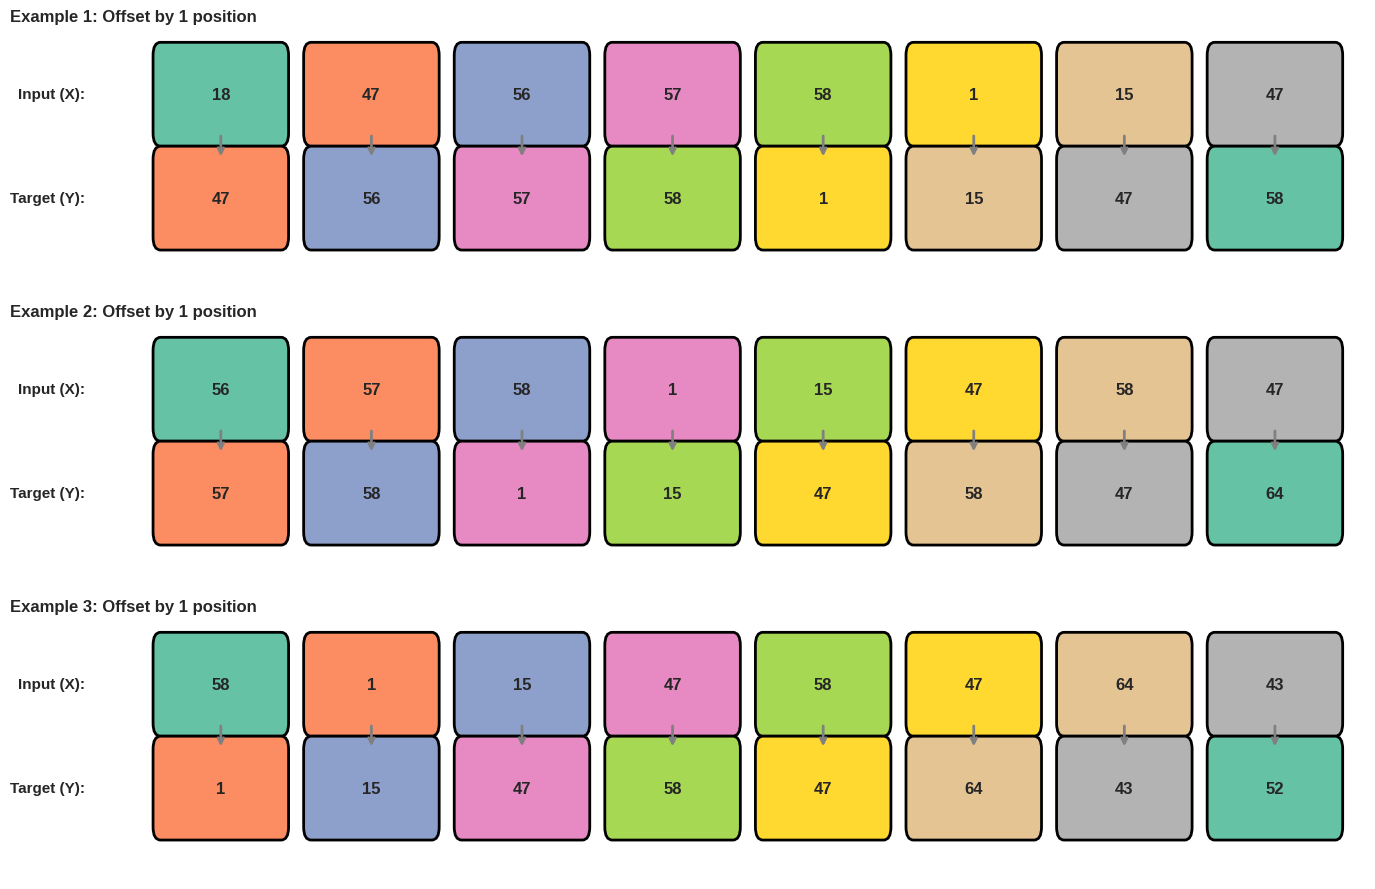


💡 Notice: Each example is offset by 1 position!


In [8]:
# Visualize the sliding window
sample_sequence = data[:20].tolist()
num_examples = 3

fig, axes = plt.subplots(num_examples, 1, figsize=(14, 3 * num_examples))
if num_examples == 1:
    axes = [axes]

colors = sns.color_palette("Set2", block_size + 1)

for idx, ax in enumerate(axes):
    start_idx = idx * 2  # Offset each example
    
    # Input sequence
    input_seq = sample_sequence[start_idx:start_idx + block_size]
    target_seq = sample_sequence[start_idx + 1:start_idx + block_size + 1]
    
    # Plot input
    for i, token in enumerate(input_seq):
        rect = FancyBboxPatch((i, 0.6), 0.8, 0.3, 
                             boxstyle="round,pad=0.05", 
                             facecolor=colors[i], 
                             edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(i + 0.4, 0.75, str(token), ha='center', va='center', 
               fontsize=12, fontweight='bold')
    
    # Plot target
    for i, token in enumerate(target_seq):
        rect = FancyBboxPatch((i, 0.2), 0.8, 0.3, 
                             boxstyle="round,pad=0.05", 
                             facecolor=colors[i + 1], 
                             edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(i + 0.4, 0.35, str(token), ha='center', va='center', 
               fontsize=12, fontweight='bold')
    
    # Arrows
    for i in range(len(input_seq)):
        ax.annotate('', xy=(i + 0.4, 0.5), xytext=(i + 0.4, 0.6),
                   arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    
    # Labels
    ax.text(-0.5, 0.75, 'Input (X):', ha='right', va='center', 
           fontsize=11, fontweight='bold')
    ax.text(-0.5, 0.35, 'Target (Y):', ha='right', va='center', 
           fontsize=11, fontweight='bold')
    
    ax.set_xlim(-1, block_size)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Example {idx + 1}: Offset by 1 position', 
                fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/data_pipeline/sliding_window.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Notice: Each example is offset by 1 position!")

---

## 4. Batch Construction

### 🎯 Why Batching?

Training on one sequence at a time is inefficient. We process **multiple sequences in parallel**.

**Batch Size**: Number of independent sequences processed simultaneously (e.g., 4, 32, 64)

### 💻 Create a Batch Function

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │                    BATCH GENERATION LOGIC                           │
# │                                                                     │
# │  Given: data with 1000 tokens, block_size=8, batch_size=4           │
# │                                                                     │
# │  Step 1: Generate random starting indices                           │
# │    ix = torch.randint(992, (4,))  # 992 = 1000 - 8                  │
# │    e.g., ix = [45, 234, 678, 901]                                   │
# │                                                                     │
# │  Step 2: Extract sequences for each starting index                  │
# │    Sequence 0: data[45:53]   → input,  data[46:54]   → target       │
# │    Sequence 1: data[234:242] → input,  data[235:243] → target       │
# │    Sequence 2: data[678:686] → input,  data[679:687] → target       │
# │    Sequence 3: data[901:909] → input,  data[902:910] → target       │
# │                                                                     │
# │  Step 3: Stack into batch tensors                                   │
# │    x shape: (4, 8)  ← 4 sequences, each 8 tokens                    │
# │    y shape: (4, 8)  ← targets offset by 1 position                  │
# └─────────────────────────────────────────────────────────────────────┘

def get_batch(data, block_size, batch_size):
    """
    Generate a batch of input-target pairs.
    
    Args:
        data: Tensor of token IDs
        block_size: Context window size
        batch_size: Number of sequences in batch
    
    Returns:
        x: Input tensor (batch_size, block_size)
        y: Target tensor (batch_size, block_size)
    """
    # Generate random starting indices
    # len(data) - block_size ensures we have room for full sequences
    ix = torch.randint(len(data) - block_size, (batch_size,))
    
    # Extract sequences
    # List comprehension creates batch_size sequences, torch.stack combines them
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    
    return x, y

# Test the function
batch_size = 4
xb, yb = get_batch(data, block_size, batch_size)

print(f"📦 Batch Created!")
print(f"\nInput shape:  {xb.shape}  (Batch × Sequence)")
print(f"Target shape: {yb.shape}  (Batch × Sequence)")
print(f"\n📥 Input batch (xb):")
print(xb)
print(f"\n📤 Target batch (yb):")
print(yb)

📦 Batch Created!

Input shape:  torch.Size([4, 8])  (Batch × Sequence)
Target shape: torch.Size([4, 8])  (Batch × Sequence)

📥 Input batch (xb):
tensor([[43,  1, 39, 50, 50,  1, 58, 46],
        [52, 10,  0, 13, 52, 42,  1, 39],
        [21,  1, 51, 59, 57, 58,  1, 59],
        [51, 63,  1, 48, 43, 61, 43, 50]])

📤 Target batch (yb):
tensor([[ 1, 39, 50, 50,  1, 58, 46, 43],
        [10,  0, 13, 52, 42,  1, 39, 44],
        [ 1, 51, 59, 57, 58,  1, 59, 57],
        [63,  1, 48, 43, 61, 43, 50, 57]])


### 🔍 Inspect Individual Sequences

In [10]:
print("🔍 Inspecting Batch Sequences:")
print("="*80)

for b in range(batch_size):
    print(f"\nSequence {b+1}:")
    print(f"Input:  {xb[b].tolist()}")
    print(f"Target: {yb[b].tolist()}")
    print(f"Decoded input:  '{decode(xb[b].tolist())}'")
    print(f"Decoded target: '{decode(yb[b].tolist())}'")

print("\n" + "="*80)

🔍 Inspecting Batch Sequences:

Sequence 1:
Input:  [43, 1, 39, 50, 50, 1, 58, 46]
Target: [1, 39, 50, 50, 1, 58, 46, 43]
Decoded input:  'e all th'
Decoded target: ' all the'

Sequence 2:
Input:  [52, 10, 0, 13, 52, 42, 1, 39]
Target: [10, 0, 13, 52, 42, 1, 39, 44]
Decoded input:  'n:
And a'
Decoded target: ':
And af'

Sequence 3:
Input:  [21, 1, 51, 59, 57, 58, 1, 59]
Target: [1, 51, 59, 57, 58, 1, 59, 57]
Decoded input:  'I must u'
Decoded target: ' must us'

Sequence 4:
Input:  [51, 63, 1, 48, 43, 61, 43, 50]
Target: [63, 1, 48, 43, 61, 43, 50, 57]
Decoded input:  'my jewel'
Decoded target: 'y jewels'



### 📊 Batch Tensor Structure

Let's visualize the 2D structure of our batch:

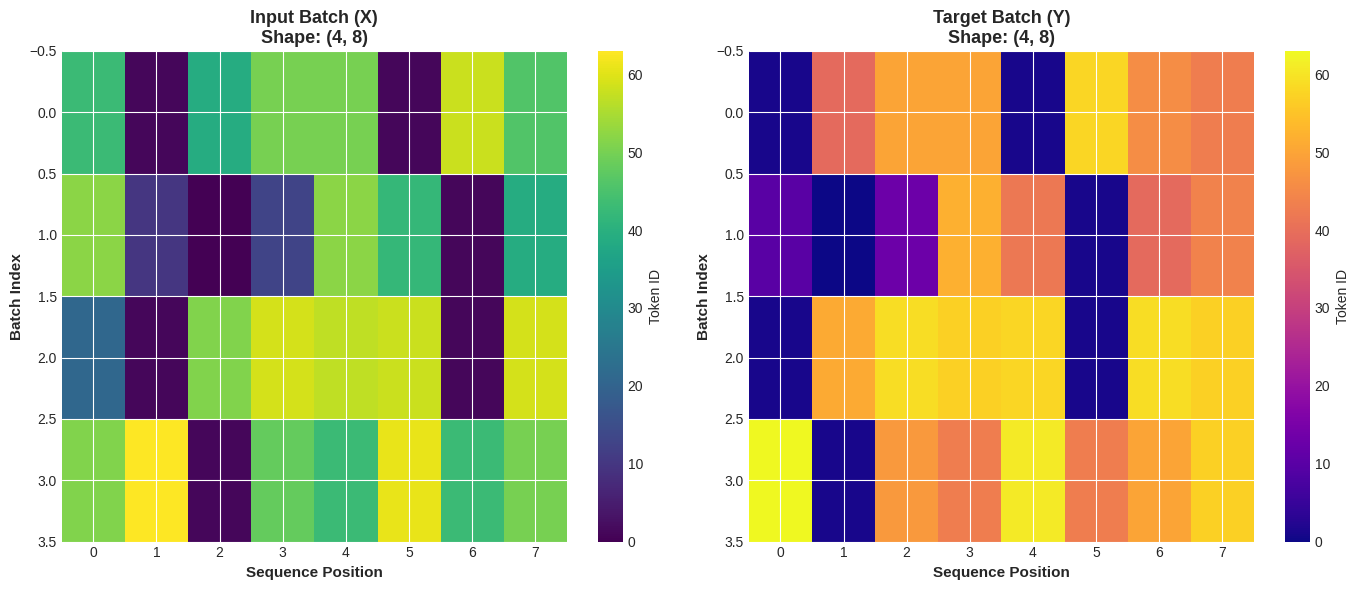


💡 Each row is an independent training sequence!


In [11]:
# Visualize batch structure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Input batch
im1 = axes[0].imshow(xb.numpy(), cmap='viridis', aspect='auto')
axes[0].set_xlabel('Sequence Position', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Batch Index', fontsize=11, fontweight='bold')
axes[0].set_title('Input Batch (X)\nShape: (4, 8)', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Token ID')

# Target batch
im2 = axes[1].imshow(yb.numpy(), cmap='plasma', aspect='auto')
axes[1].set_xlabel('Sequence Position', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Batch Index', fontsize=11, fontweight='bold')
axes[1].set_title('Target Batch (Y)\nShape: (4, 8)', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Token ID')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/data_pipeline/batch_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Each row is an independent training sequence!")

---

## 5. PyTorch Dataset & DataLoader

### 🎯 Professional Data Pipeline

Let's create a proper PyTorch Dataset and DataLoader for production-quality code.

### 💻 Custom Dataset Class

In [12]:
class TextDataset(Dataset):
    """
    PyTorch Dataset for text data.
    
    Args:
        data: Tensor of token IDs
        block_size: Context window size
    """
    
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size
    
    def __len__(self):
        # Number of possible starting positions
        return len(self.data) - self.block_size
    
    def __getitem__(self, idx):
        # Get input and target
        x = self.data[idx:idx+self.block_size]
        y = self.data[idx+1:idx+self.block_size+1]
        return x, y

# Create dataset
dataset = TextDataset(data, block_size)

print(f"📊 Dataset Created!")
print(f"Total samples: {len(dataset):,}")
print(f"Block size: {block_size}")

# Test dataset
x_sample, y_sample = dataset[0]
print(f"\n🧪 Sample from dataset:")
print(f"Input:  {x_sample}")
print(f"Target: {y_sample}")

📊 Dataset Created!
Total samples: 1,115,386
Block size: 8

🧪 Sample from dataset:
Input:  tensor([18, 47, 56, 57, 58,  1, 15, 47])
Target: tensor([47, 56, 57, 58,  1, 15, 47, 58])


### 🔄 Create DataLoader

In [13]:
# Create DataLoader
batch_size = 32
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,  # Shuffle for better training
    drop_last=True  # Drop incomplete batches
)

print(f"🔄 DataLoader Created!")
print(f"Batch size: {batch_size}")
print(f"Number of batches: {len(dataloader)}")
print(f"Total samples per epoch: {len(dataloader) * batch_size:,}")

# Test DataLoader
for xb, yb in dataloader:
    print(f"\n📦 First batch from DataLoader:")
    print(f"Input shape:  {xb.shape}")
    print(f"Target shape: {yb.shape}")
    break  # Just show first batch

🔄 DataLoader Created!
Batch size: 32
Number of batches: 34855
Total samples per epoch: 1,115,360

📦 First batch from DataLoader:
Input shape:  torch.Size([32, 8])
Target shape: torch.Size([32, 8])


---

## 6. Train/Validation Split

### 🎯 Why Split?

We need to:
- **Train** on one portion of data
- **Validate** on another portion (to detect overfitting)

Typical split: **90% train, 10% validation**

### 💻 Implementation

In [14]:
# Split data
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"📊 Data Split:")
print(f"Total tokens:      {len(data):,}")
print(f"Training tokens:   {len(train_data):,} ({len(train_data)/len(data)*100:.1f}%)")
print(f"Validation tokens: {len(val_data):,} ({len(val_data)/len(data)*100:.1f}%)")

# Create separate datasets
train_dataset = TextDataset(train_data, block_size)
val_dataset = TextDataset(val_data, block_size)

print(f"\n📚 Datasets:")
print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print(f"\n🔄 DataLoaders:")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

📊 Data Split:
Total tokens:      1,115,394
Training tokens:   1,003,854 (90.0%)
Validation tokens: 111,540 (10.0%)

📚 Datasets:
Training samples:   1,003,846
Validation samples: 111,532

🔄 DataLoaders:
Training batches:   31370
Validation batches: 3485


### 📊 Visualize Split

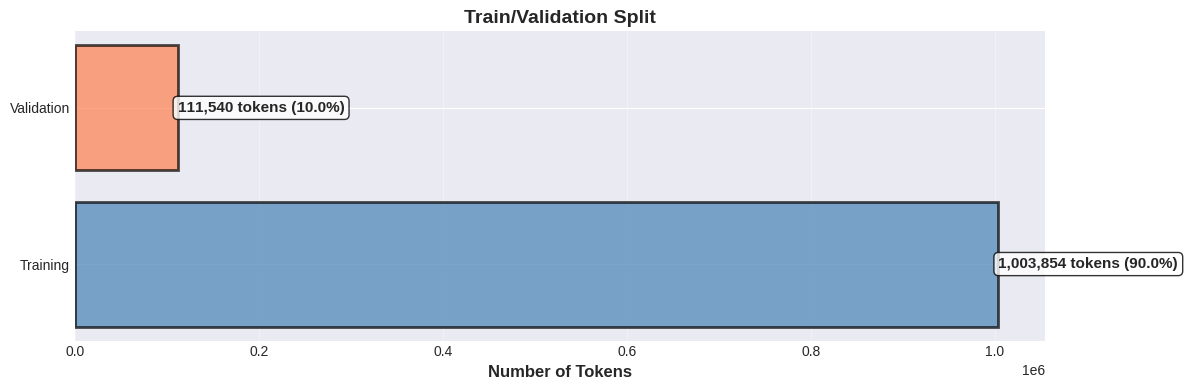


💡 Validation set is used to check for overfitting!


In [15]:
# Visualize train/val split
fig, ax = plt.subplots(figsize=(12, 4))

# Create bars
categories = ['Training', 'Validation']
sizes = [len(train_data), len(val_data)]
colors = ['steelblue', 'coral']

bars = ax.barh(categories, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add labels
for bar, size in zip(bars, sizes):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
           f'{size:,} tokens ({size/len(data)*100:.1f}%)',
           ha='left', va='center', fontsize=11, fontweight='bold', 
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Number of Tokens', fontsize=12, fontweight='bold')
ax.set_title('Train/Validation Split', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/data_pipeline/train_val_split.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Validation set is used to check for overfitting!")

---

## 7. Visualization

### 🎨 Complete Pipeline Diagram

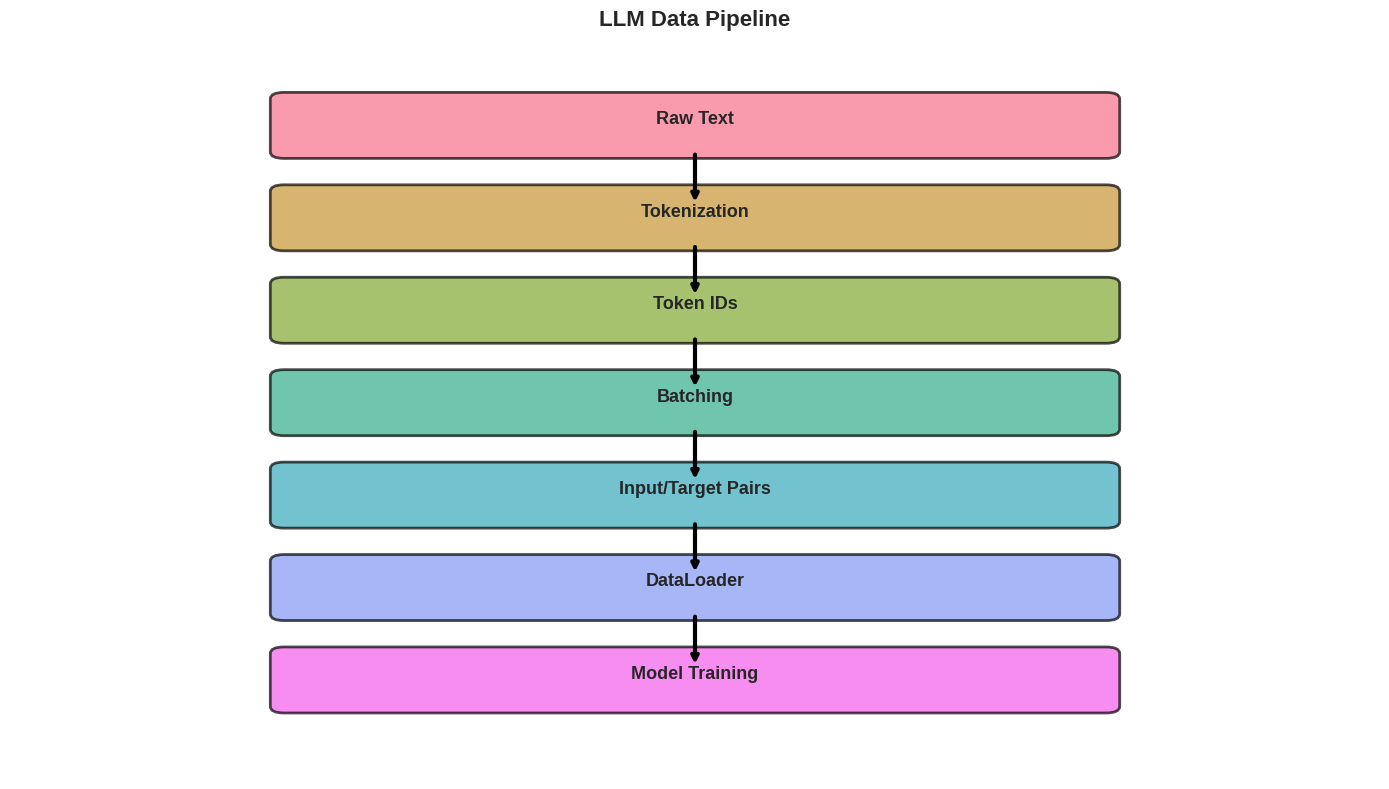

✅ Pipeline diagram created!


In [16]:
# Create comprehensive pipeline diagram
fig, ax = plt.subplots(figsize=(14, 8))

stages = [
    "Raw Text",
    "Tokenization",
    "Token IDs",
    "Batching",
    "Input/Target Pairs",
    "DataLoader",
    "Model Training"
]

colors = sns.color_palette("husl", len(stages))

for i, (stage, color) in enumerate(zip(stages, colors)):
    y = 1 - (i * 0.14)
    
    # Box
    rect = FancyBboxPatch((0.2, y - 0.05), 0.6, 0.08,
                         boxstyle="round,pad=0.01",
                         facecolor=color, edgecolor='black', 
                         linewidth=2, alpha=0.7)
    ax.add_patch(rect)
    
    # Text
    ax.text(0.5, y, stage, ha='center', va='center',
           fontsize=13, fontweight='bold')
    
    # Arrow
    if i < len(stages) - 1:
        ax.annotate('', xy=(0.5, y - 0.13), xytext=(0.5, y - 0.05),
                   arrowprops=dict(arrowstyle='->', lw=3, color='black'))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)
ax.axis('off')
ax.set_title('LLM Data Pipeline', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/data_pipeline/complete_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Pipeline diagram created!")

### 📊 Batch Statistics

In [17]:
# Analyze batch statistics
print("📊 Batch Statistics:")
print("="*80)

# Get a batch
xb, yb = next(iter(train_loader))

print(f"Batch shape:        {xb.shape}")
print(f"Batch size:         {xb.shape[0]}")
print(f"Sequence length:    {xb.shape[1]}")
print(f"Total tokens:       {xb.numel():,}")
print(f"\nData type:          {xb.dtype}")
print(f"Device:             {xb.device}")
print(f"Memory (MB):        {xb.element_size() * xb.numel() / 1024 / 1024:.2f}")

print(f"\n📈 Token Statistics:")
print(f"Min token ID:       {xb.min().item()}")
print(f"Max token ID:       {xb.max().item()}")
print(f"Unique tokens:      {len(torch.unique(xb))}")

print("\n" + "="*80)

📊 Batch Statistics:
Batch shape:        torch.Size([32, 8])
Batch size:         32
Sequence length:    8
Total tokens:       256

Data type:          torch.int64
Device:             cpu
Memory (MB):        0.00

📈 Token Statistics:
Min token ID:       0
Max token ID:       63
Unique tokens:      42



### 🎯 Training Loop Preview

Here's how you would use the DataLoader in training:

In [18]:
# Simulated training loop (no actual model yet)
print("🎓 Training Loop Preview:")
print("="*80)

num_epochs = 2
batches_to_show = 3

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 40)
    
    for batch_idx, (xb, yb) in enumerate(train_loader):
        if batch_idx < batches_to_show:
            print(f"  Batch {batch_idx + 1}: x={xb.shape}, y={yb.shape}")
        elif batch_idx == batches_to_show:
            print(f"  ... ({len(train_loader) - batches_to_show} more batches)")
            break

print("\n" + "="*80)
print("\n💡 In actual training, each batch would be:")
print("   1. Fed through the model (forward pass)")
print("   2. Loss calculated (cross-entropy)")
print("   3. Gradients computed (backward pass)")
print("   4. Weights updated (optimizer step)")

🎓 Training Loop Preview:

Epoch 1/2
----------------------------------------
  Batch 1: x=torch.Size([32, 8]), y=torch.Size([32, 8])
  Batch 2: x=torch.Size([32, 8]), y=torch.Size([32, 8])
  Batch 3: x=torch.Size([32, 8]), y=torch.Size([32, 8])
  ... (31367 more batches)

Epoch 2/2
----------------------------------------
  Batch 1: x=torch.Size([32, 8]), y=torch.Size([32, 8])
  Batch 2: x=torch.Size([32, 8]), y=torch.Size([32, 8])
  Batch 3: x=torch.Size([32, 8]), y=torch.Size([32, 8])
  ... (31367 more batches)


💡 In actual training, each batch would be:
   1. Fed through the model (forward pass)
   2. Loss calculated (cross-entropy)
   3. Gradients computed (backward pass)
   4. Weights updated (optimizer step)


---

## 8. Key Takeaways

### ✅ What We Learned

1. **Sliding Window Technique**:
   - Extract fixed-size chunks from data
   - Block size = context window (how far back model can look)
   - One sequence → Multiple training examples

2. **Input-Target Pairs**:
   - Target is input shifted by 1 position
   - `x = data[i:i+block_size]`
   - `y = data[i+1:i+block_size+1]`
   - Enables parallel prediction of all positions

3. **Batching**:
   - Process multiple sequences simultaneously
   - Batch shape: (batch_size, block_size)
   - Efficient GPU utilization

4. **PyTorch Pipeline**:
   - `Dataset`: Defines how to access data
   - `DataLoader`: Handles batching, shuffling, parallelization
   - Professional, production-ready code

5. **Train/Val Split**:
   - 90% training, 10% validation (typical)
   - Validation detects overfitting
   - Never train on validation data!

### 🎯 Next Steps

In **Notebook 4**, we'll implement **Token Embeddings**:
- Convert token IDs to dense vectors
- Learnable lookup table
- Shape: (batch_size, block_size) → (batch_size, block_size, n_embd)

### 💾 Save Configuration

In [19]:
# Save data configuration
import pickle

data_config = {
    'block_size': block_size,
    'batch_size': batch_size,
    'vocab_size': len(chars),
    'train_size': len(train_data),
    'val_size': len(val_data),
    'stoi': stoi,
    'itos': itos
}

with open(f'{DATA_DIR}/data_config.pkl', 'wb') as f:
    pickle.dump(data_config, f)

print("✅ Data configuration saved to f'{DATA_DIR}/data_config.pkl'")
print(f"\n📊 Configuration Summary:")
print(f"Block size:    {block_size}")
print(f"Batch size:    {batch_size}")
print(f"Vocab size:    {len(chars)}")
print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples:   {len(val_dataset):,}")

✅ Data configuration saved to f'{DATA_DIR}/data_config.pkl'

📊 Configuration Summary:
Block size:    8
Batch size:    32
Vocab size:    65
Train samples: 1,003,846
Val samples:   111,532


---

## 📚 References

1. **Vizuara AI Lecture 9**: [Creating Input-Target Data Pairs](https://www.youtube.com/watch?v=iQZFH8dr2yI)

2. **PyTorch Documentation**:
   - [Dataset & DataLoader](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)
   - [Data Loading Tutorial](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)

3. **Sebastian Raschka's Book**: Chapter 2 - Data Loading and Preprocessing

---

<div style="text-align: center; padding: 20px; background-color: #f0f0f0; border-radius: 10px;">
    <h2>🎉 Congratulations!</h2>
    <p>You've built a complete data pipeline for LLM training!</p>
    <p><strong>Next:</strong> Notebook 4 - Token Embeddings</p>
</div>